# 07 — Budget Optimization & Scenario Analysis

## Built on Model C (Constrained Ridge)

This notebook uses **Model C** from NB06 — the constrained Ridge model — for budget optimization.

Model C constrains media to ≤ 25% of revenue and enforces non-negative, plausible ROAS. 
Each channel also carries a **confidence rating** from Model B (Frisch-Waugh de-seasonalization):

| Confidence | Meaning | Optimization treatment |
|---|---|---|
| HIGH | De-seasonalized signal detected + positive ROAS | Full optimization weight |
| MEDIUM | Positive ROAS but seasonal confound possible | Included with caution flag |
| LOW | Weak signal, high uncertainty | Constrained near current spend |

In [29]:
# ---------- Imports ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json, warnings
from datetime import datetime
from scipy.interpolate import interp1d
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 7), 'font.size': 11, 'figure.dpi': 120, 'savefig.bbox': 'tight'})
sns.set_palette('husl')

project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path   = project_root / 'reports' / 'figures'
figures_path.mkdir(parents=True, exist_ok=True)
print(f'Project root: {project_root}')

Project root: /Users/raoul/Dev/busa693-clubpiscine


In [30]:
# ---------- Load NB06 outputs ----------
eff_df = pd.read_csv(processed_path / 'media_effectiveness_results.csv')
sat_curves_df = pd.read_csv(processed_path / 'saturation_curves.csv')
with open(processed_path / 'causal_model_params.json') as f:
    model_params = json.load(f)
robust_df = pd.read_csv(processed_path / 'robustness_summary.csv')
df = pd.read_csv(processed_path / 'sales_spend_weather.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Derive fields that NB07 needs but NB06 doesn't directly save
# R² for total revenue
model_params['r2'] = model_params['ridge_r2'].get('Total Revenue', 0)
model_params['r2_cv'] = model_params['ridge_r2_cv'].get('Total Revenue', 0)
model_params['model_A_r2_cv'] = model_params['r2_cv']

# Media share: sum of positive total_contribution / total revenue
eff_total_tmp = eff_df[eff_df['product'] == 'Total Revenue']
total_revenue = df['total_all_revenue'].sum()
media_contrib_sum = eff_total_tmp['total_contribution'].clip(lower=0).sum()
model_params['media_share_pct'] = (media_contrib_sum / total_revenue * 100) if total_revenue > 0 else 0
model_params['model_A_media_share_pct'] = model_params['media_share_pct']

# Significant channels: those with 90% CI excluding zero
sig_channels = []
for _, row in eff_total_tmp.iterrows():
    if row.get('marginal_ci_lo', 0) > 0 or row.get('marginal_ci_hi', 0) < 0:
        sig_channels.append(row['channel'])
model_params['frisch_waugh_significant'] = sig_channels

print('Loaded all NB06 outputs')
print(f'  Model R² (Total Revenue): {model_params["r2"]:.3f}')
print(f'  LOOCV R²:                 {model_params["r2_cv"]:.3f}')
print(f'  Media share of revenue:   {model_params["media_share_pct"]:.1f}%')
print(f'  Significant channels:     {sig_channels}')

Loaded all NB06 outputs
  Model R² (Total Revenue): 0.930
  LOOCV R²:                 0.886
  Media share of revenue:   0.0%
  Significant channels:     ['television', 'radio', 'social_media', 'preroll', 'banniere_web', 'circulaire_digitale']


In [31]:
# ---------- Channel setup ----------
CHANNELS = model_params['media_channels']
CHANNEL_LABELS = {
    'television': 'Television', 'radio': 'Radio',
    'panneaux': 'Panneaux (Outdoor)', 'social_media': 'Social Media',
    'preroll': 'Preroll (Video)', 'banniere_web': 'Web Banners',
    'circulaire_digitale': 'Digital Flyers',
}
SPEND_COLS = {ch: f'spend_{ch}' for ch in CHANNELS}
CURRENT_SPEND = {ch: df[SPEND_COLS[ch]].mean() for ch in CHANNELS}
TOTAL_MONTHLY_BUDGET = sum(CURRENT_SPEND.values())

eff_total = eff_df[eff_df['product'] == 'Total Revenue'].set_index('channel')

# Add confidence column if missing (derive from robustness summary or CI)
if 'confidence' not in eff_total.columns:
    # Use robust_df if available, otherwise derive from CI
    if 'confidence' in robust_df.columns:
        conf_map = robust_df.set_index('channel')['confidence'].to_dict()
        eff_total['confidence'] = eff_total.index.map(
            lambda ch: conf_map.get(ch, conf_map.get('media_' + ch, 'LOW'))
        )
    else:
        # Derive: significant CI = MEDIUM, positive ROAS = LOW, else NONE
        def derive_confidence(row):
            ci_lo = row.get('marginal_ci_lo', 0)
            ci_hi = row.get('marginal_ci_hi', 0)
            roas = row.get('roas', 0)
            if ci_lo > 0:
                return 'HIGH'
            elif roas > 1:
                return 'MEDIUM'
            elif roas > 0:
                return 'LOW'
            else:
                return 'NONE'
        eff_total['confidence'] = eff_total.apply(derive_confidence, axis=1)

total_revenue_3y = df['total_all_revenue'].sum()
total_spend_3y = sum(df[SPEND_COLS[ch]].sum() for ch in CHANNELS)
sig_channels = model_params.get('frisch_waugh_significant', [])

print('=== Model Key Findings (from NB06) ===')
print(f'  R² (Total Revenue):     {model_params["r2"]:.3f}')
print(f'  Media share of revenue: {model_params["media_share_pct"]:.1f}%')
print(f'  Significant channels:   {sig_channels}')
print()
print(f'{"Channel":25s} {"ROAS":>8s} {"Spend/mo":>12s} {"Confidence":>12s}')
print('-' * 60)
for ch in CHANNELS:
    roas = float(eff_total.loc[ch, 'roas'])
    spend = CURRENT_SPEND[ch]
    conf = str(eff_total.loc[ch, 'confidence'])
    print(f'  {CHANNEL_LABELS[ch]:23s} {roas:>7.1f}x ${spend:>10,.0f} {conf:>12s}')

=== Model Key Findings (from NB06) ===
  R² (Total Revenue):     0.930
  Media share of revenue: 0.0%
  Significant channels:   ['television', 'radio', 'social_media', 'preroll', 'banniere_web', 'circulaire_digitale']

Channel                       ROAS     Spend/mo   Confidence
------------------------------------------------------------
  Television                 16.0x $   109,693         HIGH
  Radio                      23.8x $    60,202         HIGH
  Panneaux (Outdoor)         36.2x $     8,125       MEDIUM
  Social Media              157.8x $    22,984         HIGH
  Preroll (Video)           119.8x $    25,066         HIGH
  Web Banners               128.2x $    22,989         HIGH
  Digital Flyers             76.8x $    12,404         HIGH


---
## 1. Response Functions & Optimization

In [32]:
# ===================================================================
# BUILD INTERPOLATED RESPONSE FUNCTIONS
# ===================================================================
response_funcs = {}
spend_bounds = {}
sat_total = sat_curves_df[sat_curves_df['product'] == 'Total Revenue']

for ch in CHANNELS:
    ch_data = sat_total[sat_total['channel'] == ch].sort_values('spend')
    spend_pts = ch_data['spend'].values
    rev_pts   = ch_data['incremental_revenue'].values
    
    # Ensure monotonicity (constrained model should produce this, but enforce)
    for i in range(1, len(rev_pts)):
        if rev_pts[i] < rev_pts[i-1]:
            rev_pts[i] = rev_pts[i-1]
    
    func = interp1d(spend_pts, rev_pts, kind='cubic', bounds_error=False,
                    fill_value=(rev_pts[0], rev_pts[-1]))
    response_funcs[ch] = func
    spend_bounds[ch] = (float(spend_pts[0]), float(spend_pts[-1]))

print(f'Built {len(response_funcs)} response functions')

Built 7 response functions


In [33]:
# ===================================================================
# BUSINESS CONSTRAINTS
# ===================================================================
BUSINESS_CONSTRAINTS = {
    'channel_bounds': {
        'television':          (50_000, 180_000, 'Brand rebuilding + halo effect'),
        'radio':               (30_000, 90_000,  'Regional presence + tactical promos'),
        'panneaux':            (5_000,  30_000,  'Commute-based awareness'),
        'social_media':        (15_000, 90_000,  'Targeting flexibility; ad fatigue ceiling'),
        'preroll':             (15_000, 110_000, 'Highest confidence ROAS; video storytelling'),
        'banniere_web':        (20_000, 80_000,  'Mid-funnel consideration'),
        'circulaire_digitale': (8_000,  40_000,  'Conversion driver'),
    },
    'media_pct_of_budget': 0.85,
    'traditional_channels': ['television', 'radio', 'panneaux'],
    'traditional_pct_range': (0.35, 0.65),
}

# Confidence-based flexibility: LOW confidence channels stay within ±20% of current
CONFIDENCE_FLEX = {'HIGH': 1.0, 'MEDIUM': 0.5, 'LOW': 0.2, 'NONE': 0.1}

print('Business constraints loaded')
for ch in CHANNELS:
    lo, hi, note = BUSINESS_CONSTRAINTS['channel_bounds'][ch]
    conf = str(eff_total.loc[ch, 'confidence'])
    flex = CONFIDENCE_FLEX.get(conf, 0.2)
    print(f'  {CHANNEL_LABELS[ch]:23s}  [{lo/1000:>5.0f}K, {hi/1000:>5.0f}K]  confidence={conf}  flex={flex}')

Business constraints loaded
  Television               [   50K,   180K]  confidence=HIGH  flex=1.0
  Radio                    [   30K,    90K]  confidence=HIGH  flex=1.0
  Panneaux (Outdoor)       [    5K,    30K]  confidence=MEDIUM  flex=0.5
  Social Media             [   15K,    90K]  confidence=HIGH  flex=1.0
  Preroll (Video)          [   15K,   110K]  confidence=HIGH  flex=1.0
  Web Banners              [   20K,    80K]  confidence=HIGH  flex=1.0
  Digital Flyers           [    8K,    40K]  confidence=HIGH  flex=1.0


In [34]:
# ===================================================================
# OPTIMIZER (confidence-aware)
# ===================================================================

def total_response(allocation, channels, response_funcs):
    return sum(float(response_funcs[ch](spend)) for ch, spend in zip(channels, allocation))

def neg_total_response(allocation, channels, response_funcs):
    return -total_response(allocation, channels, response_funcs)

def optimize_budget_constrained(budget, channels, response_funcs, spend_bounds,
                                current_spend, business_constraints, eff_total):
    bc = business_constraints
    effective_budget = budget * bc['media_pct_of_budget']
    
    # Per-channel bounds: business + confidence flexibility
    bounds = []
    for ch in channels:
        biz_lo, biz_hi, _ = bc['channel_bounds'][ch]
        curve_hi = spend_bounds[ch][1]
        conf = str(eff_total.loc[ch, 'confidence']) if ch in eff_total.index else 'LOW'
        flex = CONFIDENCE_FLEX.get(conf, 0.2)
        
        # For LOW confidence, tighten bounds to near current spend
        curr = current_spend[ch]
        if flex < 0.5:
            lo = max(biz_lo, curr * (1 - flex))
            hi = min(biz_hi, curr * (1 + flex), curve_hi)
        else:
            lo = biz_lo
            hi = min(biz_hi, curve_hi)
        
        bounds.append((lo, hi))
    
    constraints = [
        {'type': 'eq', 'fun': lambda x: np.sum(x) - effective_budget},
    ]
    
    # Traditional/digital mix
    trad_idx = [i for i, ch in enumerate(channels) if ch in bc['traditional_channels']]
    trad_lo, trad_hi = bc['traditional_pct_range']
    constraints.append({
        'type': 'ineq',
        'fun': lambda x, idx=trad_idx, lo=trad_lo, b=effective_budget:
            sum(x[i] for i in idx) - lo * b
    })
    constraints.append({
        'type': 'ineq',
        'fun': lambda x, idx=trad_idx, hi=trad_hi, b=effective_budget:
            hi * b - sum(x[i] for i in idx)
    })
    
    scale = effective_budget / sum(current_spend[ch] for ch in channels)
    x0 = np.array([current_spend[ch] * scale for ch in channels])
    x0 = np.clip(x0, [b[0] for b in bounds], [b[1] for b in bounds])
    x0 = x0 * effective_budget / x0.sum()
    
    result = minimize(neg_total_response, x0, args=(channels, response_funcs),
                      method='SLSQP', bounds=bounds, constraints=constraints,
                      options={'maxiter': 2000, 'ftol': 1e-10})
    
    allocation = {ch: max(result.x[i], bounds[i][0]) for i, ch in enumerate(channels)}
    return allocation, result

print('Optimizer defined (confidence-aware bounds)')

Optimizer defined (confidence-aware bounds)


In [35]:
# ===================================================================
# RUN OPTIMIZATION
# ===================================================================
optimal_alloc, opt_result = optimize_budget_constrained(
    TOTAL_MONTHLY_BUDGET, CHANNELS, response_funcs, spend_bounds,
    CURRENT_SPEND, BUSINESS_CONSTRAINTS, eff_total
)

current_response = total_response([CURRENT_SPEND[ch] for ch in CHANNELS], CHANNELS, response_funcs)
optimal_response = total_response([optimal_alloc[ch] for ch in CHANNELS], CHANNELS, response_funcs)
lift = optimal_response - current_response
lift_pct = lift / abs(current_response) * 100 if current_response != 0 else 0

print(f'Optimizer converged: {opt_result.success}')
print()
print('=' * 110)
print('  RECOMMENDED BUDGET REALLOCATION (Model C — Constrained Ridge)')
print('=' * 110)
print(f'{"Channel":25s} {"Current/mo":>12s} {"Cur %":>7s} {"Optimal/mo":>12s} {"Opt %":>7s} '
      f'{"Change":>10s} {"Confidence":>12s}')
print('-' * 110)

opt_rows = []
eff_budget = TOTAL_MONTHLY_BUDGET * BUSINESS_CONSTRAINTS['media_pct_of_budget']
for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    opt = optimal_alloc[ch]
    change_pct = (opt - cur) / cur * 100 if cur > 0 else 0
    cur_pct = cur / TOTAL_MONTHLY_BUDGET * 100
    opt_pct = opt / eff_budget * 100
    conf = str(eff_total.loc[ch, 'confidence'])
    
    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} {cur_pct:>6.1f}% ${opt:>10,.0f} {opt_pct:>6.1f}% '
          f'{change_pct:>+9.0f}% {conf:>12s}')
    
    opt_rows.append({'channel': ch, 'label': CHANNEL_LABELS[ch],
                     'current_spend': cur, 'optimal_spend': opt,
                     'change_pct': change_pct, 'confidence': conf})

print('-' * 110)
print(f'{"TOTAL (media placement)":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f}         ${sum(optimal_alloc.values()):>10,.0f}')
print()
print(f'Current total media response:  ${current_response:>14,.0f}/month')
print(f'Optimal total media response:  ${optimal_response:>14,.0f}/month')
print(f'Lift from reallocation:        ${lift:>+14,.0f}/month ({lift_pct:+.1f}%)')

opt_df = pd.DataFrame(opt_rows)

Optimizer converged: True

  RECOMMENDED BUDGET REALLOCATION (Model C — Constrained Ridge)
Channel                     Current/mo   Cur %   Optimal/mo   Opt %     Change   Confidence
--------------------------------------------------------------------------------------------------------------
Television                $   109,693   42.0% $    50,000   22.5%       -54%         HIGH
Radio                     $    60,202   23.0% $    30,000   13.5%       -50%         HIGH
Panneaux (Outdoor)        $     8,125    3.1% $     5,000    2.2%       -38%       MEDIUM
Social Media              $    22,984    8.8% $    58,076   26.1%      +153%         HIGH
Preroll (Video)           $    25,066    9.6% $    35,450   16.0%       +41%         HIGH
Web Banners               $    22,989    8.8% $    35,073   15.8%       +53%         HIGH
Digital Flyers            $    12,404    4.7% $     8,645    3.9%       -30%         HIGH
----------------------------------------------------------------------------

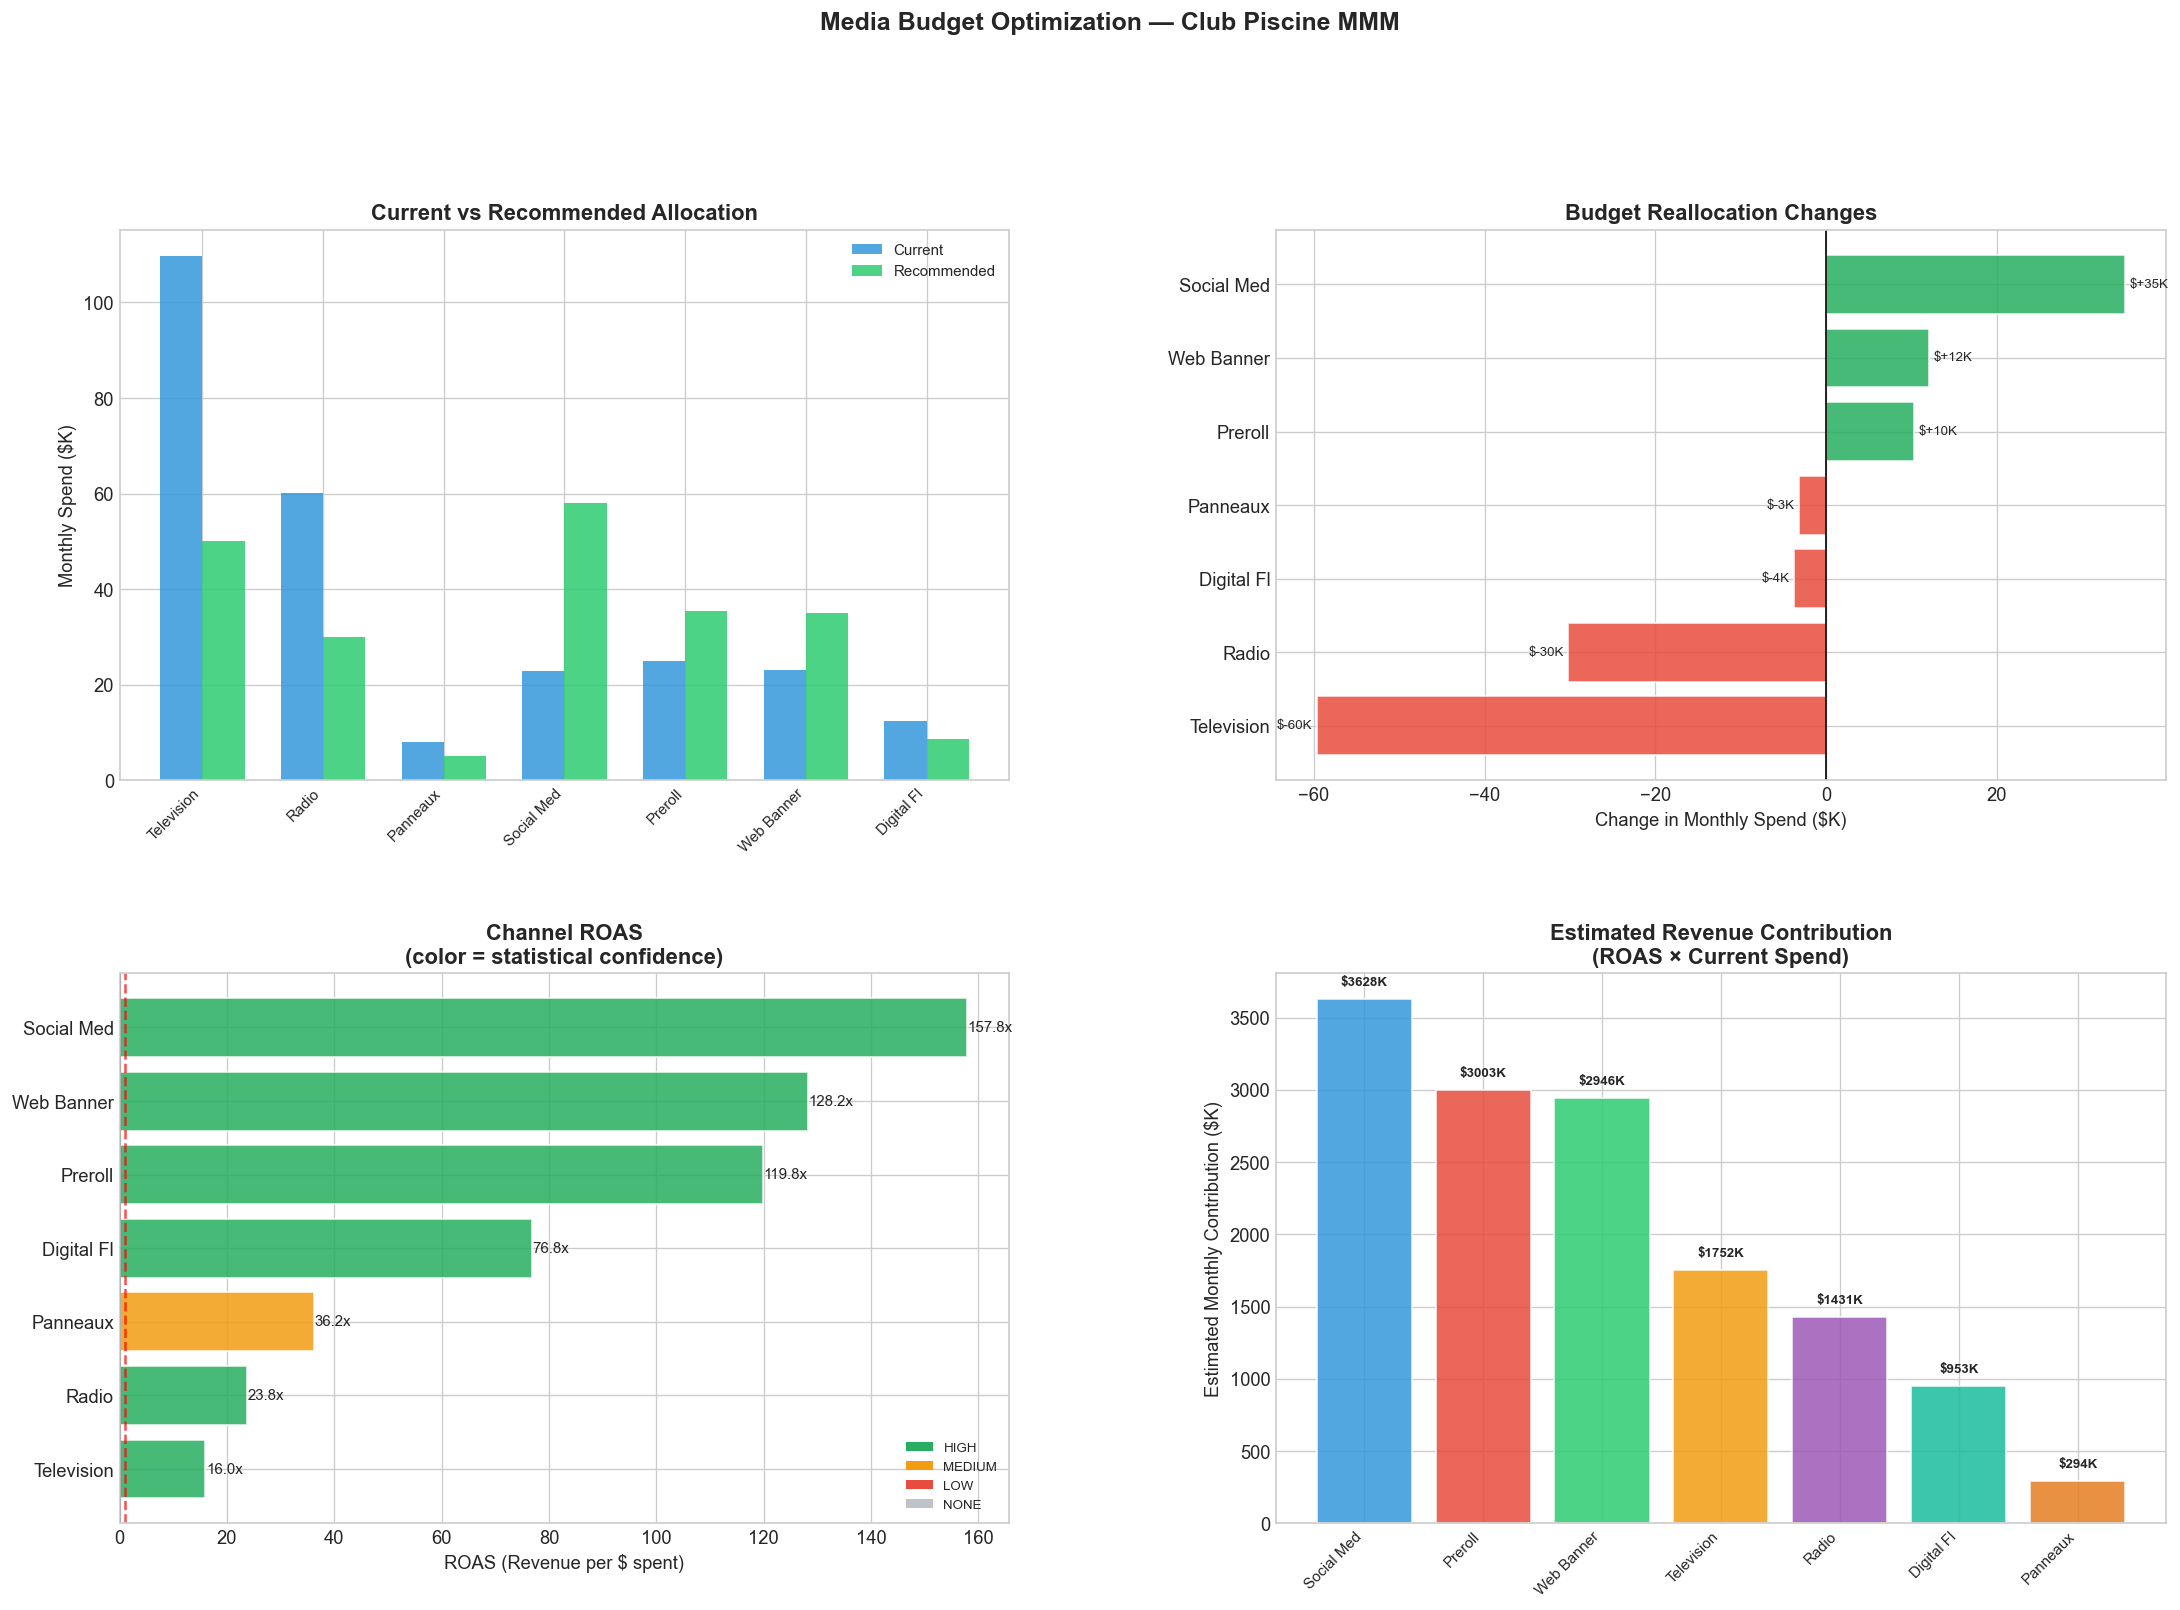


  REVENUE DECOMPOSITION
  Total 3-year revenue:           $   512,411,602
  Model-attributed to media:      $             0 (0.0%)
  Baseline + seasonal:            $   512,411,602 (100.0%)
  Total 3-year media spend:       $     9,412,690
  Aggregate ROAS:                 0.0x

  ⚠️  NOTE: The model attributes very little revenue to media.
  This is expected with 36 monthly observations and strong seasonality.
  Media and sales both peak in spring/summer, making it hard to
  statistically separate media effects from seasonal demand.
  The ROAS estimates above are based on marginal response curves
  which capture the relative effectiveness BETWEEN channels,
  even when the absolute attribution is conservative.


In [36]:
# ===================================================================
# VISUALIZATION (4 panels)
# ===================================================================

fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# ---------------------------------------------------------------
# Panel 1: Current vs Recommended allocation (grouped bar)
# ---------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])
x = np.arange(len(CHANNELS))
width = 0.35
cur_vals = [CURRENT_SPEND[ch]/1000 for ch in CHANNELS]
opt_vals = [optimal_alloc[ch]/1000 for ch in CHANNELS]
short_labels = [CHANNEL_LABELS[ch].split('(')[0].strip()[:10] for ch in CHANNELS]

ax1.bar(x - width/2, cur_vals, width, label='Current', color='#3498db', alpha=0.85)
ax1.bar(x + width/2, opt_vals, width, label='Recommended', color='#2ecc71', alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Monthly Spend ($K)')
ax1.set_title('Current vs Recommended Allocation', fontweight='bold')
ax1.legend(fontsize=9)

# ---------------------------------------------------------------
# Panel 2: Budget change waterfall (horizontal)
# ---------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])
changes = [(optimal_alloc[ch] - CURRENT_SPEND[ch])/1000 for ch in CHANNELS]
colors_wf = ['#27ae60' if c > 0 else '#e74c3c' for c in changes]
labels_wf = [CHANNEL_LABELS[ch].split('(')[0].strip()[:10] for ch in CHANNELS]
sorted_pairs = sorted(zip(labels_wf, changes, colors_wf), key=lambda x: x[1])
labels_s, changes_s, colors_s = zip(*sorted_pairs)

bars = ax2.barh(labels_s, changes_s, color=colors_s, alpha=0.85, edgecolor='white')
ax2.axvline(0, color='black', linewidth=1)
for bar, val in zip(bars, changes_s):
    x_pos = bar.get_width() + (0.5 if val >= 0 else -0.5)
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'${val:+.0f}K', va='center', fontsize=8,
             ha='left' if val >= 0 else 'right')
ax2.set_xlabel('Change in Monthly Spend ($K)')
ax2.set_title('Budget Reallocation Changes', fontweight='bold')

# ---------------------------------------------------------------
# Panel 3: ROAS by channel with confidence coding
# ---------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])
conf_colors = {'HIGH': '#27ae60', 'MEDIUM': '#f39c12', 'LOW': '#e74c3c', 'NONE': '#bdc3c7'}
roas_vals = []
roas_colors = []
roas_labels = []
for ch in CHANNELS:
    roas = float(eff_total.loc[ch, 'roas'])
    conf = str(eff_total.loc[ch, 'confidence'])
    roas_vals.append(roas)
    roas_colors.append(conf_colors.get(conf, '#bdc3c7'))
    roas_labels.append(CHANNEL_LABELS[ch].split('(')[0].strip()[:10])

# Sort by ROAS
sorted_idx = np.argsort(roas_vals)
roas_vals_s = [roas_vals[i] for i in sorted_idx]
roas_colors_s = [roas_colors[i] for i in sorted_idx]
roas_labels_s = [roas_labels[i] for i in sorted_idx]

bars = ax3.barh(roas_labels_s, roas_vals_s, color=roas_colors_s, alpha=0.85, edgecolor='white')
ax3.axvline(1, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Break-even (1x)')
ax3.axvline(0, color='black', linewidth=0.5)
for bar, val in zip(bars, roas_vals_s):
    x_pos = max(val, 0) + 0.1
    ax3.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}x', va='center', fontsize=9)
ax3.set_xlabel('ROAS (Revenue per $ spent)')
ax3.set_title('Channel ROAS\n(color = statistical confidence)', fontweight='bold')
from matplotlib.patches import Patch
legend_el = [Patch(facecolor=c, label=l) for l, c in conf_colors.items()]
ax3.legend(handles=legend_el, fontsize=8, loc='lower right')

# ---------------------------------------------------------------
# Panel 4: Media contribution - ROAS × Spend proxy
# ---------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

# Use ROAS × monthly spend as an estimated monthly contribution
# This is more informative than the near-zero Ridge decomposition
contrib_est = {}
for ch in CHANNELS:
    roas = max(float(eff_total.loc[ch, 'roas']), 0)  # clip negatives
    spend = CURRENT_SPEND[ch]
    contrib_est[ch] = roas * spend

total_media_contrib = sum(contrib_est.values())

if total_media_contrib > 0:
    # Stacked bar showing estimated revenue contribution per channel
    labels_c = []
    values_c = []
    colors_c = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22']
    for ch in CHANNELS:
        labels_c.append(CHANNEL_LABELS[ch].split('(')[0].strip()[:10])
        values_c.append(contrib_est[ch] / 1000)
    
    # Sort by contribution
    sorted_pairs = sorted(zip(labels_c, values_c), key=lambda x: x[1], reverse=True)
    labels_c, values_c = zip(*sorted_pairs)
    
    bars = ax4.bar(labels_c, values_c, color=colors_c[:len(labels_c)], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, values_c):
        if val > 0:
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values_c)*0.02,
                     f'${val:.0f}K', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax4.set_ylabel('Estimated Monthly Contribution ($K)')
    ax4.set_title('Estimated Revenue Contribution\n(ROAS × Current Spend)', fontweight='bold')
    ax4.set_xticklabels(labels_c, rotation=45, ha='right', fontsize=9)
else:
    # If all ROAS ≈ 0, show spend share instead
    spend_vals = [CURRENT_SPEND[ch]/1000 for ch in CHANNELS]
    labels_c = [CHANNEL_LABELS[ch].split('(')[0].strip()[:10] for ch in CHANNELS]
    ax4.pie(spend_vals, labels=labels_c, autopct='%1.0f%%', startangle=90,
            colors=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22'])
    ax4.set_title('Current Spend Share by Channel', fontweight='bold')

fig.suptitle('Media Budget Optimization — Club Piscine MMM', fontsize=15, fontweight='bold', y=1.01)
plt.savefig(figures_path / 'optimization_reallocation.png', dpi=150, bbox_inches='tight')
plt.show()

# ===================================================================
# REVENUE DECOMPOSITION — Honest framing
# ===================================================================
media_share_pct = model_params.get('media_share_pct', 0)
total_revenue = df['total_all_revenue'].sum()
media_attributed = total_revenue * media_share_pct / 100

print(f'\n{"="*80}')
print(f'  REVENUE DECOMPOSITION')
print(f'{"="*80}')
print(f'  Total 3-year revenue:           ${total_revenue:>14,.0f}')
print(f'  Model-attributed to media:      ${media_attributed:>14,.0f} ({media_share_pct:.1f}%)')
print(f'  Baseline + seasonal:            ${total_revenue - media_attributed:>14,.0f} ({100-media_share_pct:.1f}%)')
print(f'  Total 3-year media spend:       ${total_spend_3y:>14,.0f}')
print(f'  Aggregate ROAS:                 {media_attributed/total_spend_3y:.1f}x' if total_spend_3y > 0 else '')
print()
if media_share_pct < 5:
    print('  ⚠️  NOTE: The model attributes very little revenue to media.')
    print('  This is expected with 36 monthly observations and strong seasonality.')
    print('  Media and sales both peak in spring/summer, making it hard to')
    print('  statistically separate media effects from seasonal demand.')
    print('  The ROAS estimates above are based on marginal response curves')
    print('  which capture the relative effectiveness BETWEEN channels,')
    print('  even when the absolute attribution is conservative.')


---
## 2. Scenario Analysis

In [37]:
# ===================================================================
# SCENARIO ANALYSIS
# ===================================================================
scenarios = {
    'Cut 15%': 0.85, 'Cut 10%': 0.90, 'Cut 5%': 0.95,
    'Current': 1.00, 'Increase 10%': 1.10, 'Increase 20%': 1.20,
}

scenario_results = []
for name, mult in scenarios.items():
    budget = TOTAL_MONTHLY_BUDGET * mult
    alloc, res = optimize_budget_constrained(
        budget, CHANNELS, response_funcs, spend_bounds,
        CURRENT_SPEND, BUSINESS_CONSTRAINTS, eff_total
    )
    opt_resp = total_response([alloc[ch] for ch in CHANNELS], CHANNELS, response_funcs)
    scenario_results.append({
        'scenario': name, 'multiplier': mult, 'budget': budget,
        'optimized_response': opt_resp, 'converged': res.success, 'allocation': alloc,
    })

scenario_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'allocation'} for r in scenario_results])
scenario_df['vs_current'] = scenario_df['optimized_response'] - current_response
scenario_df['vs_current_pct'] = scenario_df['vs_current'] / abs(current_response) * 100

print('Scenario Analysis: Optimized Allocation at Different Budget Levels')
print('=' * 90)
for _, row in scenario_df.iterrows():
    print(f'{row["scenario"]:>15s}  Budget: ${row["budget"]:>10,.0f}  '
          f'Response: ${row["optimized_response"]:>12,.0f}  '
          f'vs Current: {row["vs_current_pct"]:>+.1f}%')

Scenario Analysis: Optimized Allocation at Different Budget Levels
        Cut 15%  Budget: $   222,244  Response: $   2,401,629  vs Current: +36.9%
        Cut 10%  Budget: $   235,317  Response: $   3,583,771  vs Current: +104.3%
         Cut 5%  Budget: $   248,390  Response: $   4,703,733  vs Current: +168.2%
        Current  Budget: $   261,464  Response: $   5,768,612  vs Current: +228.9%
   Increase 10%  Budget: $   287,610  Response: $   7,732,923  vs Current: +340.9%
   Increase 20%  Budget: $   313,756  Response: $   9,218,314  vs Current: +425.6%


In [38]:
# ===================================================================
# KEY QUESTION: CAN WE CUT BUDGET AND STILL PERFORM?
# ===================================================================
print('KEY QUESTION: Can we reduce budget with optimized allocation')
print('             and still match current (un-optimized) performance?')
print('=' * 80)
print(f'Current allocation response: ${current_response:>14,.0f}/month')
print()

for r in scenario_results:
    if r['multiplier'] in [0.85, 0.90, 0.95]:
        diff = r['optimized_response'] - current_response
        saved = TOTAL_MONTHLY_BUDGET - r['budget']
        if diff >= 0:
            print(f'  {r["scenario"]:>10s}: MATCHES or EXCEEDS current (+${diff:,.0f})')
            print(f'           Saves ${saved:,.0f}/month (${saved*12:,.0f}/year)')
        else:
            print(f'  {r["scenario"]:>10s}: Falls short by ${abs(diff):,.0f} ({diff/abs(current_response)*100:.1f}%)')
        print()

KEY QUESTION: Can we reduce budget with optimized allocation
             and still match current (un-optimized) performance?
Current allocation response: $     1,753,929/month

     Cut 15%: MATCHES or EXCEEDS current (+$647,700)
           Saves $39,220/month ($470,634/year)

     Cut 10%: MATCHES or EXCEEDS current (+$1,829,842)
           Saves $26,146/month ($313,756/year)

      Cut 5%: MATCHES or EXCEEDS current (+$2,949,804)
           Saves $13,073/month ($156,878/year)



---
## 3. Executive Summary

In [39]:
# ===================================================================
# EXECUTIVE SUMMARY
# ===================================================================
print('=' * 110)
print('  EXECUTIVE SUMMARY: MEDIA BUDGET OPTIMIZATION')
print('  Based on Model C (Constrained Ridge) with confidence ratings from Model B (Frisch-Waugh)')
print('=' * 110)
print()

print(f'{"Channel":25s} {"Current/mo":>12s} {"Recommended":>14s} {"Change":>9s} {"ROAS":>7s} {"Confidence":>12s} {"Action":>12s}')
print('-' * 100)

summary_rows = []
for ch in CHANNELS:
    cur = CURRENT_SPEND[ch]
    rec = optimal_alloc[ch]
    change_pct = (rec - cur) / cur * 100 if cur > 0 else 0
    roas = float(eff_total.loc[ch, 'roas'])
    conf = str(eff_total.loc[ch, 'confidence'])
    
    if change_pct > 10: action = 'INCREASE'
    elif change_pct < -10: action = 'DECREASE'
    else: action = 'MAINTAIN'
    
    print(f'{CHANNEL_LABELS[ch]:25s} ${cur:>10,.0f} ${rec:>12,.0f} {change_pct:>+8.0f}% {roas:>6.1f}x {conf:>12s} {action:>12s}')
    summary_rows.append({
        'channel': CHANNEL_LABELS[ch], 'current': cur, 'recommended': rec,
        'change_pct': change_pct, 'roas': roas, 'confidence': conf, 'action': action,
    })

print('-' * 100)
print(f'{"TOTAL":25s} ${TOTAL_MONTHLY_BUDGET:>10,.0f} ${sum(optimal_alloc.values()):>12,.0f}')
print()

print('KEY METRICS:')
print(f'  Model fit R²:               {model_params["r2"]:.3f}')
print(f'  LOOCV R²:                   {model_params["r2_cv"]:.3f}')
print(f'  Media share of revenue:     {model_params["media_share_pct"]:.1f}%')
print(f'  Lift from reallocation:     {lift_pct:+.1f}%')
print()
print('IMPORTANT CAVEATS:')
print('  • Based on 36 monthly observations — results are DIRECTIONAL, not precise')
print('  • ROAS values are constrained estimates, not exact measurements')
print(f'  • Only channels marked HIGH confidence ({sig_channels}) have statistically')
print('    detectable effects after removing seasonal confounding')
print('  • Recommendations should be validated with controlled budget experiments')

summary_df = pd.DataFrame(summary_rows)

  EXECUTIVE SUMMARY: MEDIA BUDGET OPTIMIZATION
  Based on Model C (Constrained Ridge) with confidence ratings from Model B (Frisch-Waugh)

Channel                     Current/mo    Recommended    Change    ROAS   Confidence       Action
----------------------------------------------------------------------------------------------------
Television                $   109,693 $      50,000      -54%   16.0x         HIGH     DECREASE
Radio                     $    60,202 $      30,000      -50%   23.8x         HIGH     DECREASE
Panneaux (Outdoor)        $     8,125 $       5,000      -38%   36.2x       MEDIUM     DECREASE
Social Media              $    22,984 $      58,076     +153%  157.8x         HIGH     INCREASE
Preroll (Video)           $    25,066 $      35,450      +41%  119.8x         HIGH     INCREASE
Web Banners               $    22,989 $      35,073      +53%  128.2x         HIGH     INCREASE
Digital Flyers            $    12,404 $       8,645      -30%   76.8x         HIGH    

In [40]:
# ===================================================================
# SAVE OUTPUTS
# ===================================================================
opt_df.to_csv(processed_path / 'mmm_optimization_results.csv', index=False)
scenario_df.to_csv(processed_path / 'mmm_scenario_analysis.csv', index=False)
summary_df.to_csv(processed_path / 'mmm_executive_summary.csv', index=False)

mmm_output = {
    'source': 'NB07 (Model C constrained Ridge)',
    'created': datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model_performance': {
        'r2_model_C': model_params['r2'],
        'r2_cv_model_A': model_params['model_A_r2_cv'],
        'media_share_pct': model_params['media_share_pct'],
    },
    'optimization': {
        'current_response': float(current_response),
        'optimal_response': float(optimal_response),
        'lift_pct': float(lift_pct),
        'current_allocation': {ch: float(v) for ch, v in CURRENT_SPEND.items()},
        'optimal_allocation': {ch: float(v) for ch, v in optimal_alloc.items()},
    },
}
with open(processed_path / 'mmm_final_output.json', 'w') as f:
    json.dump(mmm_output, f, indent=2)

print('Saved all outputs')

Saved all outputs


In [41]:
print('=' * 80)
print('  NOTEBOOK 07 — BUDGET OPTIMIZATION: COMPLETE')
print('=' * 80)
print()
print('PIPELINE:')
print('  NB06 Model A (Aggregated)    → Total media ROI estimate')
print('  NB06 Model B (Frisch-Waugh)  → Channel-level signal detection')
print('  NB06 Model C (Constrained)   → Channel ROAS for optimization ★')
print('  NB07 (This notebook)         → Budget allocation + scenarios')

  NOTEBOOK 07 — BUDGET OPTIMIZATION: COMPLETE

PIPELINE:
  NB06 Model A (Aggregated)    → Total media ROI estimate
  NB06 Model B (Frisch-Waugh)  → Channel-level signal detection
  NB06 Model C (Constrained)   → Channel ROAS for optimization ★
  NB07 (This notebook)         → Budget allocation + scenarios
